# Human Resources Candidate Ranking
## Notebook 01 — Data, Relevance Labels, Duplicates, and Text Representation

This notebook establishes the evidence base for the candidate-ranking system. It covers the submitted candidate data, the human 0–3 relevance target, duplicate-safe grouping, and the lexical text representations used later for ranking.

The business task is **ranking**, not hire/no-hire classification. The two search intents used throughout the project are **“aspiring human resources”** and **“seeking human resources.”** A ranking score therefore means *textual relevance to the search objective*; it is not a probability of employability, job performance, or hiring success.

In [1]:
from pathlib import Path
import hashlib
import math
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

# The final repository is intentionally flat. This makes the notebook work
# whether it is launched from the repository root or from a notebook viewer.
ROOT = Path.cwd()
if not (ROOT / "potential-talents-labelled.csv").exists() and (ROOT.parent / "potential-talents-labelled.csv").exists():
    ROOT = ROOT.parent

RAW_DATA = ROOT / "potential-talents.csv"
LABELLED_DATA = ROOT / "potential-talents-labelled.csv"
QUERIES = ("aspiring human resources", "seeking human resources")

_TOKEN_RE = re.compile(r"[a-z0-9]+")
_HR_TERMS = {"human", "resource", "resources", "hr", "hris"}
_INTENT_TERMS = {"aspiring", "seeking", "student", "internship", "entry", "entrylevel"}


def normalize_text(text):
    """Normalize text while preserving HR and search-intent meaning."""
    text = "" if pd.isna(text) else str(text)
    text = text.lower().replace("&", " and ")
    text = re.sub(r"\bhr\b", " human resources ", text)
    text = re.sub(r"\bentry[- ]level\b", " entrylevel ", text)
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def tokenize(text):
    return _TOKEN_RE.findall(normalize_text(text))


def parse_connections(value):
    """Convert values such as '500+' to a numeric count for diagnostics."""
    match = re.search(r"\d+", str(value).replace(",", ""))
    return float(match.group()) if match else np.nan


def stable_group_key(job_title, location, connection_num):
    """Stable duplicate key: normalized title + location + parsed connections."""
    payload = "|".join([
        normalize_text(job_title),
        normalize_text(location),
        "" if pd.isna(connection_num) else f"{float(connection_num):g}",
    ])
    return hashlib.sha1(payload.encode("utf-8")).hexdigest()[:16]


def load_labelled_data():
    data = pd.read_csv(LABELLED_DATA)

    # The submitted labelled file stores the human grade in this source column.
    # From here onward the notebook uses the clearer name `relevance_grade`.
    source_label_column = "final_revised_grade"
    data["relevance_grade"] = data[source_label_column].astype(int)
    data["connection_num"] = data["connection"].map(parse_connections)
    data["title_norm"] = data["job_title"].map(normalize_text)
    data["group_key"] = [
        stable_group_key(t, l, c)
        for t, l, c in zip(data.job_title, data.location, data.connection_num)
    ]
    return data


def deduplicate(data):
    """Collapse repeated rows to one modelling/evaluation unit per profile group."""
    return (
        data.sort_values("id")
        .groupby("group_key", sort=False)
        .agg(
            canonical_id=("id", "min"),
            member_ids=("id", lambda s: tuple(int(x) for x in s)),
            duplicate_count=("id", "size"),
            job_title=("job_title", "first"),
            location=("location", "first"),
            connection_num=("connection_num", "first"),
            title_norm=("title_norm", "first"),
            relevance_grade=("relevance_grade", "first"),
        )
        .reset_index()
        .sort_values("canonical_id")
        .reset_index(drop=True)
    )


class BM25Index:
    """Small transparent BM25 implementation used for lexical diagnostics."""
    def __init__(self, k1=1.5, b=0.75):
        self.k1 = float(k1)
        self.b = float(b)

    def fit(self, documents):
        self.docs = [list(doc) for doc in documents]
        self.n_docs = len(self.docs)
        self.term_freqs = [Counter(doc) for doc in self.docs]
        self.doc_len = np.array([len(doc) for doc in self.docs], dtype=float)
        self.avgdl = float(self.doc_len.mean()) if self.n_docs else 0.0
        self.doc_freq = Counter()
        for doc in self.docs:
            self.doc_freq.update(set(doc))
        return self

    def _idf(self, term):
        df = self.doc_freq.get(term, 0)
        return math.log(1.0 + (self.n_docs - df + 0.5) / (df + 0.5))

    def score(self, query_tokens):
        scores = np.zeros(self.n_docs, dtype=float)
        for term in query_tokens:
            idf = self._idf(term)
            for i, tf in enumerate(self.term_freqs):
                f = tf.get(term, 0)
                if not f:
                    continue
                norm = 1 - self.b + self.b * (self.doc_len[i] / max(self.avgdl, 1e-12))
                scores[i] += idf * (f * (self.k1 + 1)) / (f + self.k1 * norm)
        return scores


def build_lexical_features(groups, query):
    docs = groups["title_norm"].tolist()
    doc_tokens = [tokenize(text) for text in docs]
    query_norm = normalize_text(query)
    query_tokens = tokenize(query)

    word_vectorizer = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
    word_matrix = word_vectorizer.fit_transform(docs + [query_norm])
    word_similarity = cosine_similarity(word_matrix[:-1], word_matrix[-1]).ravel()

    char_vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), sublinear_tf=True)
    char_matrix = char_vectorizer.fit_transform(docs + [query_norm])
    char_similarity = cosine_similarity(char_matrix[:-1], char_matrix[-1]).ravel()

    bm25 = BM25Index().fit(doc_tokens).score(query_tokens)
    qset = set(query_tokens)
    qhr = qset & _HR_TERMS
    qintent = qset & _INTENT_TERMS

    rows = []
    for i, row in groups.iterrows():
        dset = set(doc_tokens[i])
        union = qset | dset
        rows.append({
            "canonical_id": int(row.canonical_id),
            "job_title": row.job_title,
            "relevance_grade": int(row.relevance_grade),
            "bm25": float(bm25[i]),
            "tfidf_word": float(word_similarity[i]),
            "tfidf_char": float(char_similarity[i]),
            "jaccard": len(qset & dset) / len(union) if union else 0.0,
            "query_containment": len(qset & dset) / len(qset) if qset else 0.0,
            "hr_overlap": len(qhr & dset) / len(qhr) if qhr else 0.0,
            "intent_overlap": len(qintent & dset) / len(qintent) if qintent else 0.0,
        })
    return pd.DataFrame(rows)


### What was done, how, and why

The setup cell imported the analysis libraries, fixed the two recruiter search queries, defined the text-normalization and duplicate-key rules, and created helper functions used throughout the notebook. Keeping these definitions in one place makes every later table and figure reproducible and ensures the same rules are applied consistently.

## 1. Dataset and unit of analysis

The source file contains 104 candidate rows with four descriptive fields: candidate ID, job title, location, and connection count. The original `fit` field is not used as a target. The labelled file adds a **human relevance grade from 0 to 3**.

A crucial distinction is that a **row is not necessarily an independent profile**. Exact repeated profiles occur in the source data, so modelling and evaluation must first collapse those repetitions into duplicate-safe profile groups.

In [2]:
df = load_labelled_data()
groups = deduplicate(df)

summary = pd.DataFrame({
    "Quantity": [
        "Raw candidate rows",
        "Unique duplicate-safe profile groups",
        "Rows attributable to repeated profiles",
    ],
    "Value": [len(df), len(groups), len(df) - len(groups)],
})

data_dictionary = pd.DataFrame({
    "Field": ["id", "job_title", "location", "connection", "fit", "relevance_grade"],
    "Role in this project": [
        "Source-row identifier used for traceability",
        "Primary text used for relevance ranking",
        "Retained as candidate context and part of duplicate identification",
        "Parsed for diagnostics; not treated as a core relevance signal",
        "Original unused field",
        "Human 0–3 relevance target used for model development and evaluation",
    ],
})

display(summary)
display(data_dictionary)
display(
    df[["id", "job_title", "location", "connection", "relevance_grade"]]
    .head(10)
    .rename(columns={"relevance_grade": "human relevance grade"})
)

,Quantity,Value
0,Raw candidate rows,104
1,Unique duplicate-safe profile groups,53
2,Rows attributable to repeated profiles,51


,Field,Role in this project
0,id,Source-row identifier used for traceability
1,job_title,Primary text used for relevance ranking
2,location,Retained as candidate context and part of dupl...
3,connection,Parsed for diagnostics; not treated as a core ...
4,fit,Original unused field
5,relevance_grade,Human 0–3 relevance target used for model deve...


,id,job_title,location,connection,human relevance grade
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,2
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,0
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,3
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,1
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,0
5,6,Aspiring Human Resources Specialist,Greater New York City Area,1,3
6,7,Student at Humber College and Aspiring Human R...,Kanada,61,2
7,8,HR Senior Specialist,San Francisco Bay Area,500+,2
8,9,Student at Humber College and Aspiring Human R...,Kanada,61,2
9,10,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,500+,3


### What was done, how, and why

The previous cell loaded the labelled data, collapsed repeated rows into duplicate-safe profile groups, and displayed the dataset summary and field roles. This establishes the correct unit of analysis before any modelling: 104 source rows represent only 53 independent profile groups.

## 2. Relevance labelling methodology

The target is deliberately **graded** rather than immediately binary because recruiter search relevance has meaningful degrees. A candidate can be unmistakably HR-related without being the strongest match for an *aspiring/seeking* HR search.

The single grade represents **overall relevance to the combined HR-search objective**. It does not represent two independent query-specific judgements.

The rubric used in the final labelled dataset is:

- **0 — Irrelevant:** no meaningful HR/search-intent alignment.
- **1 — Weak or adjacent:** some HR-adjacent evidence, but a material intent mismatch remains.
- **2 — Clearly relevant:** a genuine HR profile, but not the strongest/direct aspiring-or-seeking target.
- **3 — Strong/direct match:** explicit HR alignment together with direct aspiring/seeking/entry intent.

The ambiguous cases are informative. HR keyword presence alone is not sufficient: a senior HR executive can be strongly HR-related yet poorly aligned to the intended search; a people-development role may be adjacent rather than direct; and generic words such as *student* or *seeking* do not establish HR relevance without the surrounding context.

In [3]:
rubric = pd.DataFrame({
    "Grade": [0, 1, 2, 3],
    "Meaning": [
        "Irrelevant",
        "Weak / adjacent",
        "Clearly HR-relevant",
        "Strong / direct target match",
    ],
    "Interpretation": [
        "No meaningful HR-search alignment",
        "Partial or adjacent evidence; intent mismatch remains",
        "Clear HR relevance but not the strongest aspiring/seeking match",
        "Direct HR relevance with explicit aspiring/seeking/entry intent",
    ],
})

example_ids = [3, 4, 66, 73, 89, 99]
label_examples = (
    groups.loc[groups.canonical_id.isin(example_ids), ["canonical_id", "job_title", "relevance_grade"]]
    .sort_values(["relevance_grade", "canonical_id"], ascending=[False, True])
    .rename(columns={
        "canonical_id": "canonical ID",
        "job_title": "candidate title",
        "relevance_grade": "human relevance grade",
    })
)

display(rubric)
display(label_examples)

,Grade,Meaning,Interpretation
0,0,Irrelevant,No meaningful HR-search alignment
1,1,Weak / adjacent,Partial or adjacent evidence; intent mismatch ...
2,2,Clearly HR-relevant,Clear HR relevance but not the strongest aspir...
3,3,Strong / direct target match,Direct HR relevance with explicit aspiring/see...


,canonical ID,candidate title,human relevance grade
2,3,Aspiring Human Resources Professional,3
21,73,"Aspiring Human Resources Manager, seeking inte...",3
14,66,Experienced Retail Manager and aspiring Human ...,2
37,89,Director Human Resources at EY,2
47,99,Seeking Human Resources Position,2
3,4,People Development Coordinator at Ryan,1


### What was done, how, and why

The previous cell displayed the 0–3 relevance rubric and concrete candidate examples from the final labels. Showing the decision boundary explicitly makes the supervision interpretable and demonstrates why simple HR-keyword matching is not sufficient: the grade depends on both HR relevance and aspiring/seeking intent.

## 3. Duplicate-safe grouping and label evidence

Repeated source rows are presentation copies, not additional independent people or additional human judgements. A stable duplicate key is therefore built from normalized title, location, and parsed connection count. The lowest source ID is retained as the canonical representative.

All model selection and evaluation later operate on the **53 unique profile groups**. Scores and grades can still be propagated back to the 104 source IDs for presentation and traceability.

,rows in group,unique groups
0,1,39
1,2,2
2,4,5
3,5,3
4,6,2
5,7,2


,relevance grade,unique profiles,raw rows after propagation
0,0,17,27
1,1,2,10
2,2,28,47
3,3,6,20


Grade-3 evidence: 6 independent profile judgements -> 20 source rows after duplicate propagation.


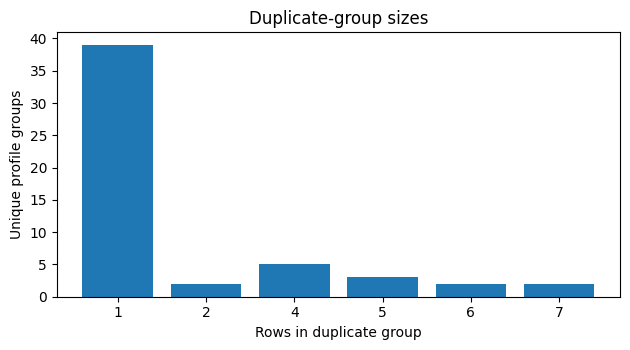

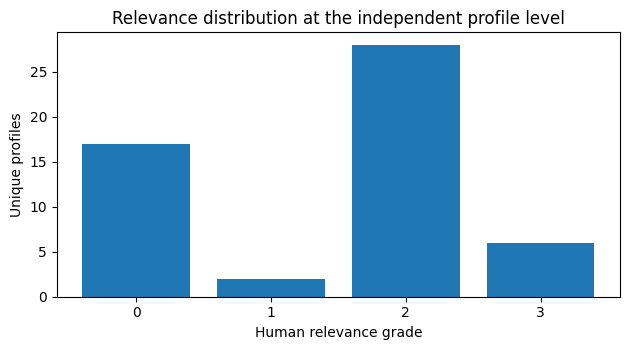

,Quantity,Value
0,Unique profiles,53.00000
1,Median connections,155.00000
2,Mean connections,241.90566
3,Maximum connections,500.00000


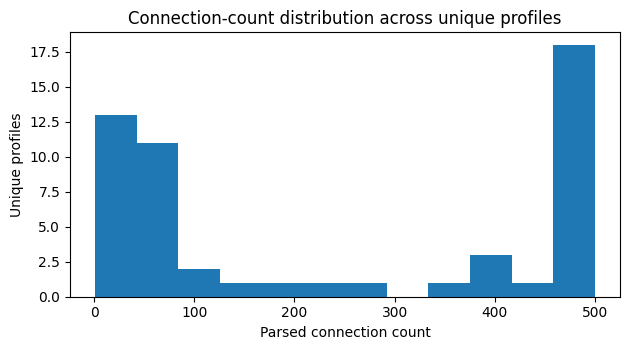

In [4]:
duplicate_sizes = (
    groups["duplicate_count"]
    .value_counts()
    .sort_index()
    .rename_axis("rows in group")
    .reset_index(name="unique groups")
)

unique_labels = (
    groups["relevance_grade"]
    .value_counts()
    .sort_index()
    .rename_axis("relevance grade")
    .reset_index(name="unique profiles")
)
raw_labels = (
    df["relevance_grade"]
    .value_counts()
    .sort_index()
    .rename_axis("relevance grade")
    .reset_index(name="raw rows after propagation")
)
label_comparison = unique_labels.merge(raw_labels, on="relevance grade")

display(duplicate_sizes)
display(label_comparison)

unique_grade3 = int(label_comparison.loc[label_comparison["relevance grade"] == 3, "unique profiles"].iloc[0])
raw_grade3 = int(label_comparison.loc[label_comparison["relevance grade"] == 3, "raw rows after propagation"].iloc[0])
print(f"Grade-3 evidence: {unique_grade3} independent profile judgements -> {raw_grade3} source rows after duplicate propagation.")

plt.figure(figsize=(6.4, 3.6))
plt.bar(duplicate_sizes["rows in group"].astype(str), duplicate_sizes["unique groups"])
plt.xlabel("Rows in duplicate group")
plt.ylabel("Unique profile groups")
plt.title("Duplicate-group sizes")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.4, 3.6))
plt.bar(unique_labels["relevance grade"].astype(str), unique_labels["unique profiles"])
plt.xlabel("Human relevance grade")
plt.ylabel("Unique profiles")
plt.title("Relevance distribution at the independent profile level")
plt.tight_layout()
plt.show()

connection_summary = pd.DataFrame({
    "Quantity": ["Unique profiles", "Median connections", "Mean connections", "Maximum connections"],
    "Value": [
        int(groups["connection_num"].notna().sum()),
        float(groups["connection_num"].median()),
        float(groups["connection_num"].mean()),
        float(groups["connection_num"].max()),
    ],
})
display(connection_summary)

plt.figure(figsize=(6.4, 3.6))
plt.hist(groups["connection_num"].dropna(), bins=12)
plt.xlabel("Parsed connection count")
plt.ylabel("Unique profiles")
plt.title("Connection-count distribution across unique profiles")
plt.tight_layout()
plt.show()


### What was done, how, and why

The previous cell quantified duplicate-group sizes, compared independent profile-level grades with their propagated raw-row counts, and visualized both distributions. It also summarized and plotted parsed connection counts across the 53 unique profiles. These diagnostics prevent duplicated rows from inflating the evidence base and show why connection count is treated only as an optional diagnostic feature rather than a core relevance signal.

## 4. From language to numerical evidence

A **corpus** is the collection of candidate titles being searched. A **token** is a normalized term such as `aspiring`, `human`, or `resources`. An **n-gram** is a short sequence of adjacent terms; for example, the word bigram `human resources` carries more context than either word alone.

**TF-IDF** converts text into a sparse numerical vector. Term frequency rewards words that occur in a title, while inverse document frequency downweights terms that appear almost everywhere. **Cosine similarity** then measures how closely a candidate-title vector points in the same direction as the query vector. The resulting number is a similarity score, not a probability.

The project uses both word-level TF-IDF and character-level TF-IDF. Character 3–5 grams add robustness to small spelling and morphological differences while remaining transparent lexical evidence.

In [5]:
text_examples = (
    df.loc[df.id.isin([3, 10, 80, 99]), ["id", "job_title"]]
    .copy()
)
text_examples["normalized title"] = text_examples["job_title"].map(normalize_text)
text_examples["tokens"] = text_examples["job_title"].map(tokenize)
display(text_examples)

query = QUERIES[0]
texts = text_examples["normalized title"].tolist() + [normalize_text(query)]
vectorizer = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
matrix = vectorizer.fit_transform(texts)
similarity = cosine_similarity(matrix[:-1], matrix[-1]).ravel()

tfidf_demo = pd.DataFrame({
    "id": text_examples.id,
    "candidate title": text_examples.job_title,
    "TF-IDF cosine similarity": similarity,
}).sort_values("TF-IDF cosine similarity", ascending=False)

display(tfidf_demo)

,id,job_title,normalized title,tokens
2,3,Aspiring Human Resources Professional,aspiring human resources professional,"[aspiring, human, resources, professional]"
9,10,Seeking Human Resources HRIS and Generalist Po...,seeking human resources hris and generalist po...,"[seeking, human, resources, hris, and, general..."
79,80,Junior MES Engineer| Information Systems,junior mes engineer information systems,"[junior, mes, engineer, information, systems]"
98,99,Seeking Human Resources Position,seeking human resources position,"[seeking, human, resources, position]"


,id,candidate title,TF-IDF cosine similarity
2,3,Aspiring Human Resources Professional,0.727913
98,99,Seeking Human Resources Position,0.307502
9,10,Seeking Human Resources HRIS and Generalist Po...,0.198062
79,80,Junior MES Engineer| Information Systems,0.000000


### What was done, how, and why

The previous cell showed how raw titles are normalized and tokenized, then built a worked TF-IDF example against the approved recruiter query. This connects the original language to the numerical similarity evidence used later by the ranking model and makes the representation step inspectable rather than a black box.

## 5. BM25 and complementary lexical features

**BM25** is a ranking-oriented bag-of-words score. Like TF-IDF, it rewards informative query terms, but it also uses term-frequency saturation and document-length normalization. The later Stage-1 model does not rely on one lexical score alone: it combines BM25, word and character TF-IDF, Jaccard overlap, query containment, HR-domain overlap, and search-intent overlap.

Connection count is retained only as a diagnostic/optional feature. It is a weak proxy for relevance and can also encode networking opportunity rather than search fit, so it is not treated as core evidence.

,canonical_id,job_title,human relevance grade,bm25,tfidf_word,tfidf_char,jaccard,query_containment,hr_overlap,intent_overlap
2,3,Aspiring Human Resources Professional,3,2.909676,0.722936,0.679497,0.750000,1.0,1.0,1.0
5,6,Aspiring Human Resources Specialist,3,2.909676,0.618920,0.631044,0.750000,1.0,1.0,1.0
45,97,Aspiring Human Resources Professional,2,2.909676,0.722936,0.679497,0.750000,1.0,1.0,1.0
21,73,"Aspiring Human Resources Manager, seeking inte...",3,2.499721,0.421272,0.576987,0.428571,1.0,1.0,1.0
27,79,Liberal Arts Major. Aspiring Human Resources A...,2,2.376955,0.322584,0.415517,0.428571,1.0,1.0,1.0
12,27,Aspiring Human Resources Management student se...,3,2.240236,0.326336,0.433093,0.375000,1.0,1.0,1.0
14,66,Experienced Retail Manager and aspiring Human ...,2,2.240236,0.340833,0.380884,0.375000,1.0,1.0,1.0
20,72,Business Management Major and Aspiring Human R...,2,2.240236,0.349598,0.435865,0.375000,1.0,1.0,1.0
6,7,Student at Humber College and Aspiring Human R...,2,2.118390,0.313560,0.415034,0.333333,1.0,1.0,1.0
30,82,Aspiring Human Resources Professional | An ene...,2,2.009114,0.268401,0.347456,0.300000,1.0,1.0,1.0


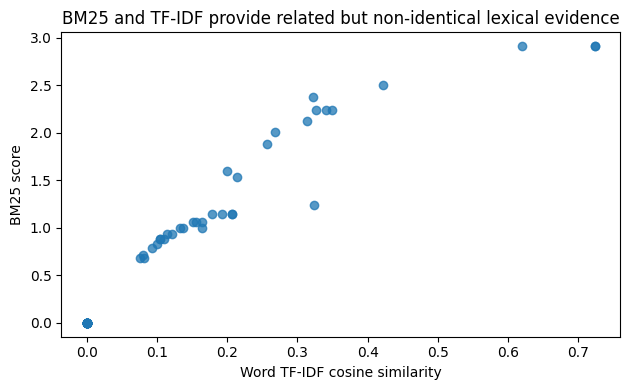

,term,unique-profile title count
0,human,36
1,resources,36
2,at,22
3,and,17
4,aspiring,13
5,seeking,10
6,professional,9
7,manager,7
8,in,6
9,university,6


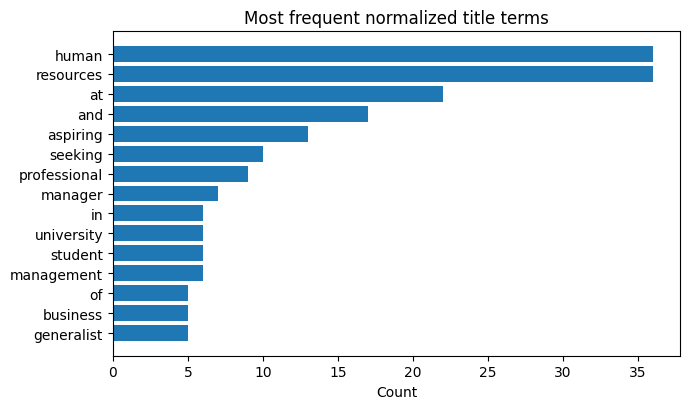

In [6]:
lexical = build_lexical_features(groups, QUERIES[0])

columns = [
    "canonical_id", "job_title", "relevance_grade", "bm25",
    "tfidf_word", "tfidf_char", "jaccard", "query_containment",
    "hr_overlap", "intent_overlap",
]
display(
    lexical[columns]
    .sort_values(["bm25", "canonical_id"], ascending=[False, True])
    .head(12)
    .rename(columns={"relevance_grade": "human relevance grade"})
)

plt.figure(figsize=(6.4, 4.0))
plt.scatter(lexical["tfidf_word"], lexical["bm25"], alpha=0.75)
plt.xlabel("Word TF-IDF cosine similarity")
plt.ylabel("BM25 score")
plt.title("BM25 and TF-IDF provide related but non-identical lexical evidence")
plt.tight_layout()
plt.show()

term_counts = Counter(token for text in groups.title_norm for token in tokenize(text))
common_terms = pd.DataFrame(term_counts.most_common(15), columns=["term", "unique-profile title count"])
display(common_terms)

plt.figure(figsize=(7.0, 4.2))
plt.barh(common_terms.term[::-1], common_terms["unique-profile title count"][::-1])
plt.xlabel("Count")
plt.title("Most frequent normalized title terms")
plt.tight_layout()
plt.show()

### What was done, how, and why

The previous cell generated the report-ready lexical evidence used to motivate the later ranking model: a candidate-level feature table, a BM25-versus-TF-IDF comparison plot, and the most frequent normalized title terms. The purpose is to show that the lexical signals are related but not identical, so the final ranker benefits from combining several transparent text signals rather than relying on one score alone.

## Notebook 01 takeaway

The source contains **104 rows but only 53 duplicate-safe profile groups**, so the effective labelled evidence base is 53 independent units. The relevance target is genuinely graded and intent-sensitive: simple HR keyword presence cannot reproduce the judgement boundary between direct, acceptable, adjacent, and irrelevant profiles.

The modelling pipeline therefore begins with duplicate-safe grouping and converts candidate/query language into several transparent lexical signals. Notebook 02 uses these representations in grouped cross-validation to compare preprocessing, retrieval, feature, and regularized ranking configurations.